# Schools, socio-economic context and "value added"

Notebook 01 looked at students. Here we look at **schools**:
1. Build a fair school-level exam score
2. How noisy are school averages?
3. How much of a school's result is explained by its students' background?
4. Which schools do better than expected? ("value added")
5. Two definitions of a "good school" that disagree
6. Municipalities: social support and results
7. Gabriel Pereira and Mouzinho da Silveira, then and now
8. Conclusions

**Data**
- ENES 2024 exam results (see notebook 01).
- **Infoescolas** (DGEEC, school year 2022/23, Científico-Humanísticos courses, mainland Portugal only). For each school it gives:
  - the % of students who **complete secondary school in 3 years**;
  - the % **expected** for students with the same profile nationally: same age, same School Social Action support (**ASE**, means-tested support for low-income families), same mother's education, and same public/private sector.

The *expected* completion rate is therefore a summary of a school's **intake**: higher means a more advantaged student body. We use it as our **socio-economic context index**.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
import style
style.apply()

FIG = ROOT / "figures"
def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=120)

PROC = ROOT / "data" / "processed"
exams = pd.read_parquet(PROC / "exams_2024.parquet")
info = pd.read_parquet(PROC / "schools_infoescolas.parquet")
mun = pd.read_parquet(PROC / "municipalities.parquet")

GP, MS = "705810", "1214002"   # Gabriel Pereira (Évora), Mouzinho da Silveira (Portalegre)
MIN_EXAMS = 30

## 1. A fair school-level exam score

A school's raw average depends on *which* exams its students sit. Maths A averages 13.7 and Geography 10.3, for example.
So we first convert each exam score into a **z-score within its subject**: 0 is the national average for that exam, +1 is one standard deviation above it.
A school's score is then the mean z-score of all its exams. The population is the same as in notebook 01: phase 1, no improvement attempts, students with an internal grade.

In [2]:
pop = exams[(exams["phase"] == 1) & ~exams["for_improvement"] & exams["internal_grade"].notna()].copy()
pop["z"] = pop.groupby("subject")["exam_score"].transform(lambda s: (s - s.mean()) / s.std())

schools = (pop.groupby(["school_dgeec", "school_name", "sector", "district", "municipality_code"])
           .agg(exams=("z", "size"), z=("z", "mean"), exam_mean=("exam_score_20", "mean"))
           .reset_index())
print(f"{len(schools)} schools in total, {(schools['exams'] >= MIN_EXAMS).sum()} with at least {MIN_EXAMS} exams")
schools.sort_values("exams", ascending=False).head()

636 schools in total, 623 with at least 30 exams


,school_dgeec,school_name,sector,district,municipality_code,exams,z,exam_mean
433,1823491,"Escola Secundária Alves Martins, Viseu",Public,Viseu,1823,1066,0.385552,13.669606
258,1312477,Externato Ribadouro,Private,Porto,1312,1034,0.590052,14.766151
438,1903460,Escola Secundária Jaime Moniz,Public,R. A. Madeira,2203,974,-0.058633,11.654517
480,303173,"Escola Secundária Carlos Amarante, Braga",Public,Braga,0303,958,0.205017,13.076618
495,308117,"Escola Secundária Martins Sarmento, Guimarães",Public,Braga,0308,922,0.031694,12.182213


## 2. How noisy are school averages?

Small schools have few exams, so their averages swing a lot by chance. A **funnel plot** shows this: the spread of school scores narrows as the number of exams grows.

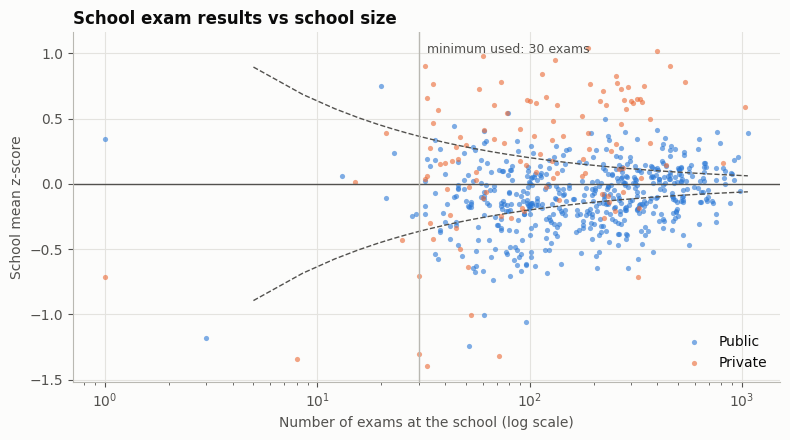

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for sector, color in style.SECTOR_COLORS.items():
    d = schools[schools["sector"] == sector]
    ax.scatter(d["exams"], d["z"], s=14, alpha=0.6, color=color, label=sector, lw=0)
n = np.linspace(5, schools["exams"].max(), 300)
for k in (2, -2):
    ax.plot(n, k / np.sqrt(n), color=style.TEXT_2, lw=1, ls="--")  # ±2 standard errors if schools were all average
ax.axhline(0, color=style.TEXT_2, lw=1)
ax.axvline(MIN_EXAMS, color=style.NEUTRAL, lw=1)
ax.text(MIN_EXAMS * 1.1, 0.97, f"minimum used: {MIN_EXAMS} exams", transform=ax.get_xaxis_transform(),
        fontsize=9, color=style.TEXT_2, va="top")
ax.set(xscale="log", xlabel="Number of exams at the school (log scale)", ylabel="School mean z-score",
       title="School exam results vs school size")
ax.legend(loc="lower right")
save_fig("05_funnel_plot")
plt.show()

Most schools sit **well outside** the dashed lines, which show the spread expected if every school were truly average. So the differences between schools are real, not just noise.
Still, the most extreme scores belong to small schools. We keep schools with at least 30 exams, and later we treat rankings of small schools with caution.

## 3. How much does intake explain?

In [4]:
df = (schools[schools["exams"] >= MIN_EXAMS]
      .merge(info[["school_dgeec", "expected_pooled", "completion_pooled", "value_added_completion", "students_ch"]],
             on="school_dgeec", how="inner")
      .dropna(subset=["expected_pooled"]))
print(f"Schools with exam data and Infoescolas context: {len(df)} "
      f"({(df['sector'] == 'Public').sum()} public, {(df['sector'] == 'Private').sum()} private)")

slope, intercept = np.polyfit(df["expected_pooled"], df["z"], 1)
r = np.corrcoef(df["expected_pooled"], df["z"])[0, 1]
print(f"Correlation between context index and exam results: r = {r:.2f}  (R² = {r**2:.2f})")
r_public = df.loc[df["sector"] == "Public", ["expected_pooled", "z"]].corr().iloc[0, 1]
print(f"Public schools only: r = {r_public:.2f}")

Schools with exam data and Infoescolas context: 555 (470 public, 85 private)
Correlation between context index and exam results: r = 0.76  (R² = 0.58)
Public schools only: r = 0.63


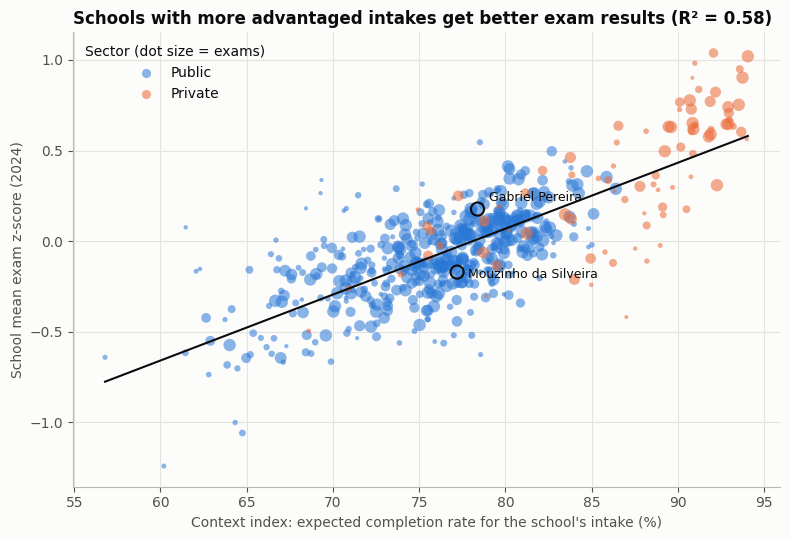

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for sector, color in style.SECTOR_COLORS.items():
    d = df[df["sector"] == sector]
    ax.scatter(d["expected_pooled"] * 100, d["z"], s=np.clip(d["exams"] / 4, 8, 80), alpha=0.55,
               color=color, label=sector, lw=0)
x = np.linspace(df["expected_pooled"].min(), df["expected_pooled"].max(), 50)
ax.plot(x * 100, slope * x + intercept, color=style.TEXT, lw=1.5)
for code_, label in [(GP, "Gabriel Pereira"), (MS, "Mouzinho da Silveira")]:
    row = df[df["school_dgeec"] == code_].iloc[0]
    ax.scatter(row["expected_pooled"] * 100, row["z"], s=90, facecolor="none", edgecolor=style.TEXT, lw=1.5, zorder=4)
    ax.annotate(label, (row["expected_pooled"] * 100, row["z"]), xytext=(8, -4 if code_ == MS else 6),
                textcoords="offset points", fontsize=9, color=style.TEXT)
ax.set(xlabel="Context index: expected completion rate for the school's intake (%)",
       ylabel="School mean exam z-score (2024)",
       title=f"Schools with more advantaged intakes get better exam results (R² = {r**2:.2f})")
ax.legend(loc="upper left", title="Sector (dot size = exams)")
save_fig("06_context_vs_results")
plt.show()

**This is the central result: about 58% of the variation in school exam results is explained by a single index of student background.**
- Schools whose students are, on paper, more likely to succeed (older students less common, fewer ASE recipients, more educated mothers) get much better exam results.
- **Private schools** cluster at the top right. They have more advantaged intakes *and* better results. Most of their advantage in raw rankings comes from who they enrol.
- Among public schools alone the relationship is a bit weaker (r ≈ 0.63) but still strong.

This is why **raw school rankings** published every year in the press mostly measure **who attends a school**, not how well it teaches.

## 4. Value added: who does better than expected?

A fairer question is: **given its intake, does a school do better or worse than expected?**
We take the regression line above as the "expected" exam result and call the vertical distance from it the school's **exam value added**.

In [6]:
df["value_added_exam"] = df["z"] - (slope * df["expected_pooled"] + intercept)
by_sector = df.groupby("sector").agg(schools=("z", "size"), raw_z=("z", "mean"),
                                     value_added_mean=("value_added_exam", "mean"),
                                     value_added_median=("value_added_exam", "median"))
gap_raw = by_sector.loc["Private", "raw_z"] - by_sector.loc["Public", "raw_z"]
gap_va = by_sector.loc["Private", "value_added_mean"] - by_sector.loc["Public", "value_added_mean"]
print(f"Private minus public: raw {gap_raw:.2f} SD, after accounting for intake {gap_va:.2f} SD")
by_sector.round(3)

Private minus public: raw 0.45 SD, after accounting for intake 0.05 SD


,schools,raw_z,value_added_mean,value_added_median
sector,,,,
Private,85,0.358,0.039,0.084
Public,470,-0.096,-0.007,-0.008


In raw terms, private schools are about **0.45 standard deviations** ahead of public ones. Once intake is accounted for, the gap shrinks to about **0.05**, roughly a 90% reduction (medians: 0.08 vs −0.01).
Most of the private-school advantage is explained by who they enrol. A small positive difference remains, but it is small compared with the differences between individual schools.

Below are the top and bottom schools by exam value added. To limit the "small school" noise from section 2, this list only includes **schools with at least 100 exams**.

In [7]:
cols = ["school_name", "sector", "exams", "z", "expected_pooled", "value_added_exam"]
big = df[df["exams"] >= 100]
print(f"{len(big)} schools with at least 100 exams")
top = big.nlargest(8, "value_added_exam")[cols]
bottom = big.nsmallest(8, "value_added_exam")[cols]
pd.concat([top.assign(group="above expected"), bottom.assign(group="below expected")]).round(2).set_index("group")

409 schools with at least 100 exams


,school_name,sector,exams,z,expected_pooled,value_added_exam
group,,,,,,
above expected,Colégio Efanor,Private,188,1.04,0.92,0.53
above expected,"Escola Básica e Secundária Josefa de Óbidos, Ó...",Public,102,0.29,0.74,0.45
above expected,Colégio Nossa Senhora do Rosário,Private,396,1.02,0.94,0.44
above expected,Grande Colégio Universal,Private,131,0.95,0.94,0.39
above expected,Colégio Nova Encosta,Private,114,0.84,0.91,0.36
above expected,"Escola Secundária Raul Proença, Caldas da Rainha",Public,400,0.41,0.80,0.34
above expected,Colégio D. Diogo de Sousa,Private,457,0.90,0.94,0.33
above expected,Colégio Campo de Flores,Private,192,0.77,0.90,0.33
below expected,"Escola Básica e Secundária de Alcains, Castelo...",Public,102,-0.52,0.78,-0.52


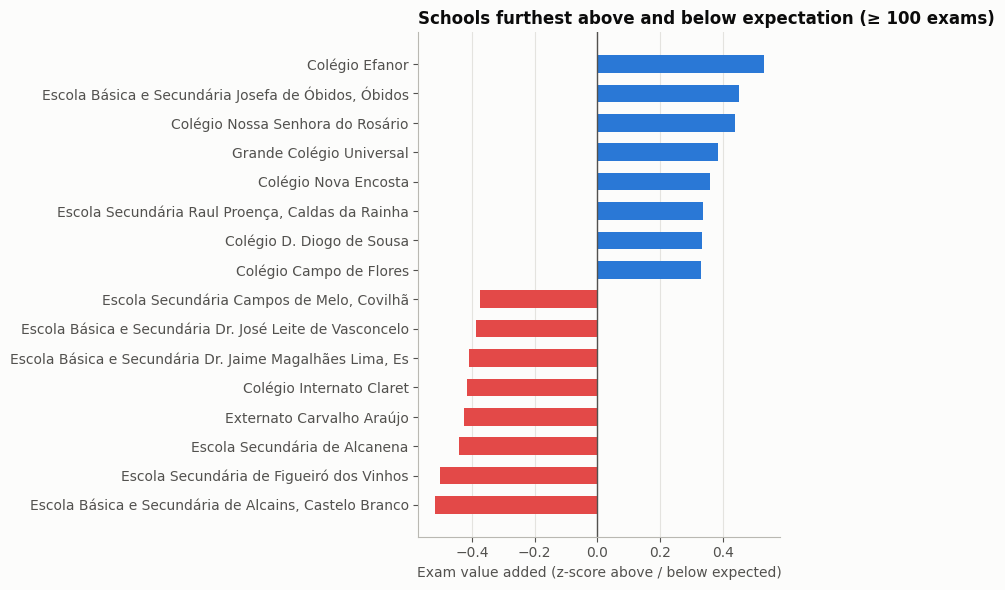

In [8]:
show = pd.concat([top, bottom]).sort_values("value_added_exam")
fig, ax = plt.subplots(figsize=(8, 6))
colors = np.where(show["value_added_exam"] > 0, style.DIV_POS, style.DIV_NEG)
ax.barh(show["school_name"].str.slice(0, 55), show["value_added_exam"], color=colors, height=0.6)
ax.axvline(0, color=style.TEXT_2, lw=1)
ax.set(xlabel="Exam value added (z-score above / below expected)",
       title="Schools furthest above and below expectation (≥ 100 exams)")
ax.grid(axis="y", visible=False)
save_fig("07_value_added_extremes")
plt.show()

Private schools are over-represented at the top of the list (6 of the top 8). Part of this may be a **ceiling effect**: the context index tops out around 94%, so it can't fully distinguish very advantaged intakes, and the straight line under-predicts at the top end (see the scatter in section 3).

⚠️ **How to read value added responsibly**
- It is a **residual**: everything the context index doesn't capture ends up in it. That includes teaching quality, but also unmeasured intake differences, student selection into exams, local job markets, and noise.
- Even with ≥ 100 exams, a single year's ranking is unstable. A serious analysis would average several years (ENES databases go back to 2008).
- So it is a tool for **asking questions** ("what is this school doing?"), not for **naming and shaming**.

## 5. Two definitions of a "good school"

Infoescolas also has its own value added: **completion value added**, the school's 3-year completion rate minus the rate expected for its intake. Do the schools that beat expectations on **exams** also beat them on **completion**?

Correlation between exam value added and completion value added: r = -0.09


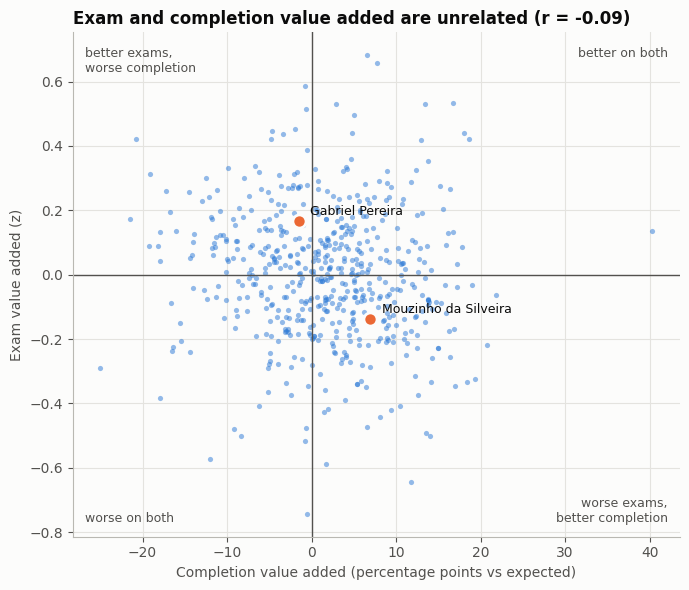

In [9]:
r_va = df[["value_added_exam", "value_added_completion"]].corr().iloc[0, 1]
print(f"Correlation between exam value added and completion value added: r = {r_va:.2f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["value_added_completion"] * 100, df["value_added_exam"], s=14, alpha=0.5, color=style.BLUE, lw=0)
ax.axhline(0, color=style.TEXT_2, lw=1)
ax.axvline(0, color=style.TEXT_2, lw=1)
for code_, label in [(GP, "Gabriel Pereira"), (MS, "Mouzinho da Silveira")]:
    row = df[df["school_dgeec"] == code_].iloc[0]
    ax.scatter(row["value_added_completion"] * 100, row["value_added_exam"], s=90, color=style.ORANGE,
               edgecolor=style.SURFACE, lw=2, zorder=4)
    ax.annotate(label, (row["value_added_completion"] * 100, row["value_added_exam"]), xytext=(8, 4),
                textcoords="offset points", fontsize=9)
kw = dict(fontsize=9, color=style.TEXT_2)
ax.text(0.98, 0.97, "better on both", transform=ax.transAxes, ha="right", va="top", **kw)
ax.text(0.02, 0.97, "better exams,\nworse completion", transform=ax.transAxes, va="top", **kw)
ax.text(0.98, 0.03, "worse exams,\nbetter completion", transform=ax.transAxes, ha="right", **kw)
ax.text(0.02, 0.03, "worse on both", transform=ax.transAxes, **kw)
ax.set(xlabel="Completion value added (percentage points vs expected)", ylabel="Exam value added (z)",
       title=f"Exam and completion value added are unrelated (r = {r_va:.2f})")
save_fig("08_two_value_added_measures")
plt.show()

**The two measures are essentially unrelated.** A school that gets its students through secondary school on time is not necessarily one whose students do well in exams, and vice versa.

There are plausible reasons:
- A school that holds students back more often may send a smaller, stronger group to the exams. Its exam results look better, while its completion rate looks worse.
- A school focused on getting every student to finish may push more borderline students to exams, or have fewer of them sit exams at all.

So "best school" depends on what you value. **Any single ranking hides this trade-off.**

## 6. Municipalities: social support and results

At municipality level, Infoescolas gives the share of secondary students receiving **ASE** (School Social Action, means-tested support). It's a more direct measure of family income than our context index.

220 municipalities with ≥ 50 exams; correlation % ASE vs exam z-score: r = -0.23


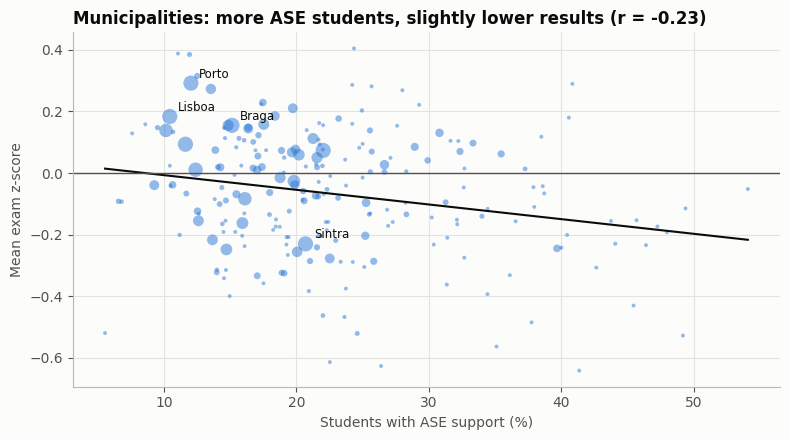

In [10]:
by_mun = (pop.groupby("municipality_code").agg(exams=("z", "size"), z=("z", "mean")).reset_index()
          .merge(mun[["municipality_code", "region_name", "pct_ase"]], on="municipality_code"))
by_mun = by_mun[by_mun["exams"] >= 50]
r_mun = by_mun[["pct_ase", "z"]].corr().iloc[0, 1]
print(f"{len(by_mun)} municipalities with ≥ 50 exams; correlation % ASE vs exam z-score: r = {r_mun:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(by_mun["pct_ase"] * 100, by_mun["z"], s=np.clip(by_mun["exams"] / 30, 8, 120), alpha=0.5, color=style.BLUE, lw=0)
b = np.polyfit(by_mun["pct_ase"] * 100, by_mun["z"], 1)
x = np.linspace(by_mun["pct_ase"].min() * 100, by_mun["pct_ase"].max() * 100, 50)
ax.plot(x, np.polyval(b, x), color=style.TEXT, lw=1.5)
for _, row in by_mun.nlargest(4, "exams").iterrows():
    ax.annotate(row["region_name"], (row["pct_ase"] * 100, row["z"]), xytext=(6, 4), textcoords="offset points", fontsize=8.5)
ax.axhline(0, color=style.TEXT_2, lw=1)
ax.set(xlabel="Students with ASE support (%)", ylabel="Mean exam z-score",
       title=f"Municipalities: more ASE students, slightly lower results (r = {r_mun:.2f})")
save_fig("09_municipalities_ase")
plt.show()

The relationship is **negative but weak** (r ≈ −0.2), much weaker than at school level. That is itself informative:
- A municipality mixes advantaged and disadvantaged schools, and the differences **within** municipalities are larger than those **between** them.
- Inequality in Portugal's exam results plays out more **between schools in the same area** than between regions.

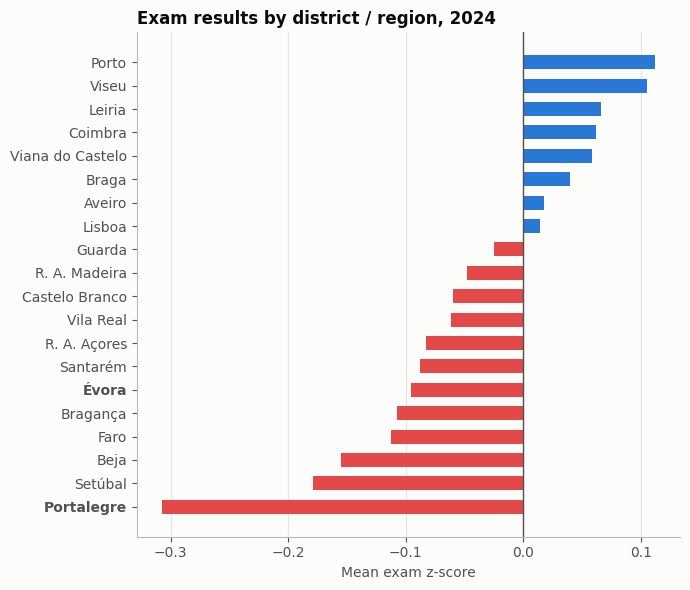

In [11]:
by_district = (pop[pop["district"] != "Estrangeiro"].groupby("district")
               .agg(exams=("z", "size"), z=("z", "mean")).sort_values("z"))
fig, ax = plt.subplots(figsize=(7, 6))
colors = np.where(by_district["z"] > 0, style.DIV_POS, style.DIV_NEG)
ax.barh(by_district.index, by_district["z"], color=colors, height=0.6)
ax.axvline(0, color=style.TEXT_2, lw=1)
for name in ["Évora", "Portalegre"]:
    i = list(by_district.index).index(name)
    ax.get_yticklabels()[i].set_fontweight("bold")
ax.set(xlabel="Mean exam z-score", title="Exam results by district / region, 2024")
ax.grid(axis="y", visible=False)
save_fig("10_districts")
plt.show()

Regional differences exist but are modest (between −0.3 and +0.1 standard deviations). **Portalegre**, home of Mouzinho da Silveira, has the lowest mean of all districts.

## 7. Gabriel Pereira and Mouzinho da Silveira, then and now

The 2005/06 study showed Gabriel Pereira (GP) ahead of Mouzinho da Silveira (MS). Where do they stand in 2024?

In [12]:
pct = lambda col, v: (df[col] < v).mean()  # percentile among the schools in this analysis
rows = []
for code_, name in [(GP, "Gabriel Pereira (Évora)"), (MS, "Mouzinho da Silveira (Portalegre)")]:
    s = df[df["school_dgeec"] == code_].iloc[0]
    rows.append({
        "School": name, "Exams 2024": int(s["exams"]),
        "Exam z-score": s["z"], "Exam percentile": pct("z", s["z"]),
        "Context index": s["expected_pooled"], "Context percentile": pct("expected_pooled", s["expected_pooled"]),
        "Exam value added (pct.)": pct("value_added_exam", s["value_added_exam"]),
        "Completion rate": s["completion_pooled"],
        "Completion value added (pct.)": pct("value_added_completion", s["value_added_completion"]),
    })
pd.DataFrame(rows).set_index("School").T.round(2)

School,Gabriel Pereira (Évora),Mouzinho da Silveira (Portalegre)
Exams 2024,420.00,390.00
Exam z-score,0.18,-0.17
Exam percentile,0.81,0.29
Context index,0.78,0.77
Context percentile,0.58,0.49
Exam value added (pct.),0.80,0.24
Completion rate,0.77,0.84
Completion value added (pct.),0.34,0.75


**A neat illustration of section 5:**
- The two schools have **almost identical intakes** (context index ≈ 0.78 vs 0.77, both near the national middle).
- **On exams, GP is clearly ahead**: around the 80th percentile, against roughly the 30th for MS. This is the same ordering as in 2005/06.
- **On completion, the order flips**: MS gets more students through secondary school on time than its intake predicts, while GP does slightly worse than expected.

So "which school is better?" has no single answer, in 2005/06 or now. It depends on whether you value exam excellence for university applicants, or getting every student to the finish line.

## 8. Conclusions

1. **Background explains most of the differences between schools.** A single intake index explains ~58% of the variation in school exam results. Raw rankings mostly measure who a school enrols.
2. **Private schools' advantage shrinks by about 90% once intake is accounted for** (from 0.45 to 0.05 standard deviations).
3. **"Good school" depends on the metric.** Exam value added and completion value added are unrelated (r ≈ −0.1).
4. **Inequality is mostly local.** Municipality-level social support explains far less than school-level context. Differences between nearby schools matter more than regional ones.
5. **The 2005/06 findings largely hold**: falling behind is the strongest warning sign, girls lead in Portuguese, and GP is still ahead of MS on grades. But in 2024 the full picture is more nuanced.

**Limitations**
- The 2024 exam takers are university applicants only, so results describe applicants, not all students.
- Infoescolas context refers to 2022/23 cohorts, while exams are from 2024. School intakes change slowly, but not instantly.
- The context index is a model-based expectation built from a few variables, not a full measure of socio-economic status.
- One year of exam data. Value added estimates should be averaged across several years before drawing conclusions about any individual school.

**Possible extensions**
- Add earlier ENES years (2008–2023) to track trends and stabilise value added.
- Use Infoescolas' 3rd-cycle (9th grade) data to follow the same schools across levels.
- Join INE municipal indicators (income, unemployment, population density) for a richer context model.